# Case
**Creates binary labels in raster format**

The labels are either based on a provided text- or Esri-shapefile.<br>
To spatially align the labels with other data sets, a template raster (base raster) can be provided.


In [10]:
import geopandas as gpd
from beak.utilities.io import data_folder


# Load data

**User definitions**

In [11]:
# Set paths
BASE_PATH = data_folder()
PATH_SHAPEFILE = BASE_PATH / "RAW" / "boundaries" / "us_alaska_ytu" / "shape_from_mag_rtp_ytu_no_gaps.shp"

# Set outut settings
EPSG = 32606
RESOLUTION = 100
DESCRIPTION = "ALASKA_YTU"
QUERY = None

# Out file path
OUT_FILE = BASE_PATH / "BASE_RASTERS" / f"EPSG_{EPSG}_RES_{RESOLUTION}_{DESCRIPTION}.tif"

**Reproject** the features based on a CRS from a template feature

Show coverage of shapefile **with** QUERY

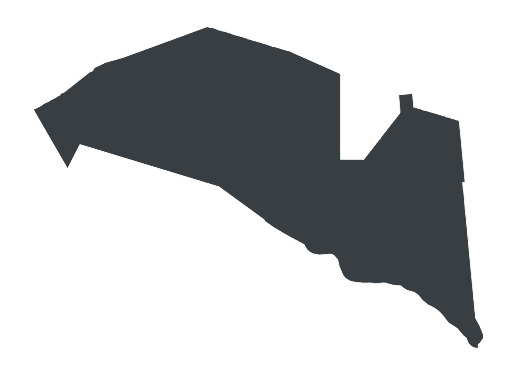

In [12]:
from beak.utilities.vector_processing import _reproject_vector_data
import matplotlib.pyplot as plt

gdf = gpd.read_file(PATH_SHAPEFILE, encoding="utf-8", query=QUERY)
gdf.plot(facecolor="#383e42", edgecolor="white", linewidth=0.5)

plt.axis("off")
plt.show()


# Create Base Raster

## From shapefile

`fill_negatives`<p>
- True will fill the nodata values with a fill value, commonly 0 (i.e., the extent of the raster is filled completeley with values)<p>
- False will only convert the queried polygons to **one** and the rest of the raster will be **nodata**<p>
**Base rasters** commonly have **nodata** (`fill_negatives=False`) instead of filled values

`snapping`<p>
We're going to use the `snap_raster_raster` function to align the base raster to the origin (0, 0)

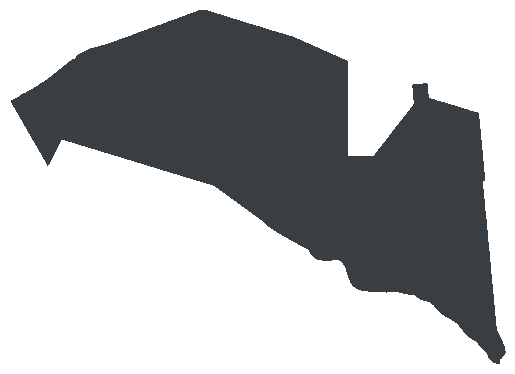

In [13]:
from beak.utilities.conversions import create_binary_raster
from beak.utilities.raster_processing import snap_raster
from matplotlib.colors import ListedColormap

base_array, base_meta = create_binary_raster(gdf, resolution=RESOLUTION, query=QUERY, all_touched=False, same_shape=True, fill_negatives=False, return_meta=True)
snapped_array, snapped_meta = snap_raster((base_array, base_meta), (0, 0))

cmap = ListedColormap(["white", "#383e42"])
cmap.set_bad("black")

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.imshow(snapped_array.squeeze(), cmap=cmap)
ax.axis("off")
plt.show()


In [14]:
from beak.utilities.io import save_raster

# Save raster
save_raster(OUT_FILE, snapped_array, metadata=snapped_meta, overwrite=True)